# Explore yfinance Data

Fetch OHLCV data for a ticker and compute metrics.

In [36]:
import yfinance as yf
import pandas as pd

TICKER = 'AAPL'
TRAIN_START = '2015-01-01'
TEST_END = '2024-12-31'

In [50]:
%pip install yfinance pandas ta matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 35.8 MB/s  0:00:00 eta 0:00:01
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 42.5 MB/s  0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Download data

In [38]:
def download_ticker(ticker: str, start: str, end: str) -> pd.DataFrame:
    df = yf.Ticker(ticker).history(start=start, end=end, auto_adjust=True)
    df.index = df.index.tz_localize(None)
    return df

In [39]:
df = download_ticker(TICKER, start=TRAIN_START, end=TEST_END)
print(f'{len(df)} rows  ({df.index[0].date()} to {df.index[-1].date()})')
df.head()

2515 rows  (2015-01-02 to 2024-12-30)


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02,24.648443,24.659508,23.754470,24.192606,212818400,0.0,0.0
2015-01-05,23.962471,24.042132,23.325184,23.511059,257142000,0.0,0.0
2015-01-06,23.575235,23.772175,23.152589,23.513277,263188400,0.0,0.0
2015-01-07,23.721278,23.942559,23.610638,23.842983,160423600,0.0,0.0
2015-01-08,24.170472,24.816610,24.053192,24.759077,237458000,0.0,0.0


In [40]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          2515 non-null   float64
 1   High          2515 non-null   float64
 2   Low           2515 non-null   float64
 3   Close         2515 non-null   float64
 4   Volume        2515 non-null   int64  
 5   Dividends     2515 non-null   float64
 6   Stock Splits  2515 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 157.2 KB


In [41]:
df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03,2515.000000,2515.000000
mean,93.535693,94.532237,92.611390,93.623189,1.171162e+08,0.003049,0.001590
std,65.177410,65.850856,64.573238,65.259577,6.839222e+07,0.024517,0.079761
min,20.488467,20.868641,20.367811,20.565865,2.323470e+07,0.000000,0.000000
25%,35.168903,35.540946,34.779569,35.138058,7.108655e+07,0.000000,0.000000
50%,64.013124,64.603170,63.447179,64.254379,1.003845e+08,0.000000,0.000000
75%,149.723870,151.665585,147.929005,149.941154,1.426222e+08,0.000000,0.000000
max,256.550832,258.448710,255.994390,257.375549,6.488252e+08,0.250000,4.000000


## 2. Compute technical indicators

The `ta` library takes the OHLCV columns and computes each indicator. Each class returns an object with methods that give back a pandas Series, which I assign as a new column on the DataFrame.

In [42]:
from ta.momentum import RSIIndicator
from ta.trend import MACD
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

features = df.copy()

### RSI

RSI is a momentum indicator that assesses the ratio of relative gain to relative loss. It determines the strength of price movements by comparing the number of positive and negative price changes (Mostafavi & Hooman, 2025). Values above 70 suggest the stock may be overbought; values below 30 suggest it may be oversold.

In [43]:
features['rsi'] = RSIIndicator(close=features['Close'], window=14).rsi()
features[['Close', 'rsi']].tail(10)

,Close,rsi
Date,,
2024-12-16,249.446289,78.747866
2024-12-17,251.870773,80.923033
2024-12-18,246.475235,64.982979
2024-12-19,248.204208,67.211791
2024-12-20,252.874390,72.334135
2024-12-23,253.649445,73.085617
2024-12-24,256.560852,75.750248
2024-12-26,257.375549,76.452787
2024-12-27,253.967392,67.626324


### MACD

MACD is derived by subtracting the 26-period EMA from the 12-period EMA. The signal line is a 9-period EMA of the MACD line itself (Mostafavi & Hooman, 2025). When the MACD line crosses above the signal line it suggests upward momentum is building; a cross below suggests the opposite.

In [44]:
macd = MACD(close=features['Close'])
features['macd']        = macd.macd()
features['macd_signal'] = macd.macd_signal()
features[['Close', 'macd', 'macd_signal']].tail(10)

,Close,macd,macd_signal
Date,,,
2024-12-16,249.446289,5.393175,4.408381
2024-12-17,251.870773,5.710391,4.668783
2024-12-18,246.475235,5.463432,4.827713
2024-12-19,248.204208,5.345609,4.931292
2024-12-20,252.874390,5.564928,5.058019
2024-12-23,253.649445,5.735170,5.193449
2024-12-24,256.560852,6.035440,5.361848
2024-12-26,257.375549,6.266906,5.542859
2024-12-27,253.967392,6.104959,5.655279


### Bollinger Bands

Bollinger Bands are volatility bands placed above and below a moving average, calculated using standard deviation. They adjust as volatility levels change. When the price reaches the upper band it may indicate an overbought signal; reaching the lower band may suggest an oversold signal (Mostafavi & Hooman, 2025).

In [45]:
bb = BollingerBands(close=features['Close'], window=20, window_dev=2)
features['bb_upper'] = bb.bollinger_hband()
features['bb_mid']   = bb.bollinger_mavg()
features['bb_lower'] = bb.bollinger_lband()
features[['Close', 'bb_upper', 'bb_mid', 'bb_lower']].tail(10)

,Close,bb_upper,bb_mid,bb_lower
Date,,,,
2024-12-16,249.446289,252.794384,237.639206,222.484028
2024-12-17,251.870773,254.373192,238.904124,223.435055
2024-12-18,246.475235,254.642505,239.886347,225.130190
2024-12-19,248.204208,254.949861,240.919248,226.888635
2024-12-20,252.874390,255.641542,242.209505,228.777469
2024-12-23,253.649445,256.204962,243.471445,230.737928
2024-12-24,256.560852,257.414134,244.729906,232.045679
2024-12-26,257.375549,258.659414,245.920298,233.181182
2024-12-27,253.967392,258.773110,246.946741,235.120372


### ATR

ATR measures price volatility. Larger true ranges indicate stronger back-and-forth price movements (Mostafavi & Hooman, 2025). It tells the model how much the stock typically moves in a day, which helps the RL agent scale its position sizing decisions.

In [46]:
features['atr'] = AverageTrueRange(
    high=features['High'], low=features['Low'], close=features['Close'], window=14
).average_true_range()
features[['Close', 'atr']].tail(10)

,Close,atr
Date,,
2024-12-16,249.446289,3.549475
2024-12-17,251.870773,3.583390
2024-12-18,246.475235,3.791611
2024-12-19,248.204208,3.869269
2024-12-20,252.874390,4.253671
2024-12-23,253.649445,4.105982
2024-12-24,256.560852,4.021364
2024-12-26,257.375549,3.909432
2024-12-27,253.967392,4.053194


### OBV

A running total of volume: it adds the day's volume when the price closes up and subtracts it when the price closes down. Rising OBV alongside rising price confirms the trend. Divergence between OBV and price can signal a coming reversal.

In [47]:
features['obv'] = OnBalanceVolumeIndicator(
    close=features['Close'], volume=features['Volume']
).on_balance_volume()
features[['Close', 'Volume', 'obv']].tail(10)

,Close,Volume,obv
Date,,,
2024-12-16,249.446289,51694800,7082443800
2024-12-17,251.870773,51356400,7133800200
2024-12-18,246.475235,56774100,7077026100
2024-12-19,248.204208,60882300,7137908400
2024-12-20,252.874390,147495300,7285403700
2024-12-23,253.649445,40858800,7326262500
2024-12-24,256.560852,23234700,7349497200
2024-12-26,257.375549,27237100,7376734300
2024-12-27,253.967392,42355300,7334379000


### HLC3

HLC3 calculates the average of the High, Low, and Close prices for a period. It is used as a smoothing technique to reduce price volatility (Mostafavi & Hooman, 2025). It gives a more stable price reference than Close alone because it accounts for the full range of the day's movement.

In [48]:
features['hlc3'] = (features['High'] + features['Low'] + features['Close']) / 3
features[['High', 'Low', 'Close', 'hlc3']].tail(10)

,High,Low,Close,hlc3
Date,,,,
2024-12-16,249.784142,246.077811,249.446289,248.436081
2024-12-17,252.218557,248.194266,251.870773,250.761199
2024-12-18,252.665679,246.167205,246.475235,248.436040
2024-12-19,250.400185,245.521352,248.204208,248.041915
2024-12-20,253.381146,244.130253,252.874390,250.128596
2024-12-23,254.027022,251.840991,253.649445,253.172486
2024-12-24,256.570768,253.669307,256.560852,255.600309
2024-12-26,258.448710,255.994390,257.375549,257.272883
2024-12-27,257.057664,251.453455,253.967392,254.159504


### Final feature set

In [49]:
features = features.dropna()
print(f'{len(features)} rows, {len(features.columns)} columns')
features.tail()

2482 rows, 16 columns


,Open,High,Low,Close,Volume,Dividends,Stock Splits,rsi,macd,macd_signal,bb_upper,bb_mid,bb_lower,atr,obv,hlc3
Date,,,,,,,,,,,,,,,,
2024-12-23,253.152619,254.027022,251.840991,253.649445,40858800,0.0,0.0,73.085617,5.735170,5.193449,256.204962,243.471445,230.737928,4.105982,7326262500,253.172486
2024-12-24,253.868050,256.570768,253.669307,256.560852,23234700,0.0,0.0,75.750248,6.035440,5.361848,257.414134,244.729906,232.045679,4.021364,7349497200,255.600309
2024-12-26,256.550832,258.448710,255.994390,257.375549,27237100,0.0,0.0,76.452787,6.266906,5.542859,258.659414,245.920298,233.181182,3.909432,7376734300,257.272883
2024-12-27,256.193162,257.057664,251.453455,253.967392,42355300,0.0,0.0,67.626324,6.104959,5.655279,258.773110,246.946741,235.120372,4.053194,7334379000,254.159504
2024-12-30,250.628701,251.890642,249.158101,250.598892,35557500,0.0,0.0,60.225572,5.639794,5.652182,258.437324,247.685520,236.933716,4.107201,7298821500,250.549212


## 3. Charts

In [51]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

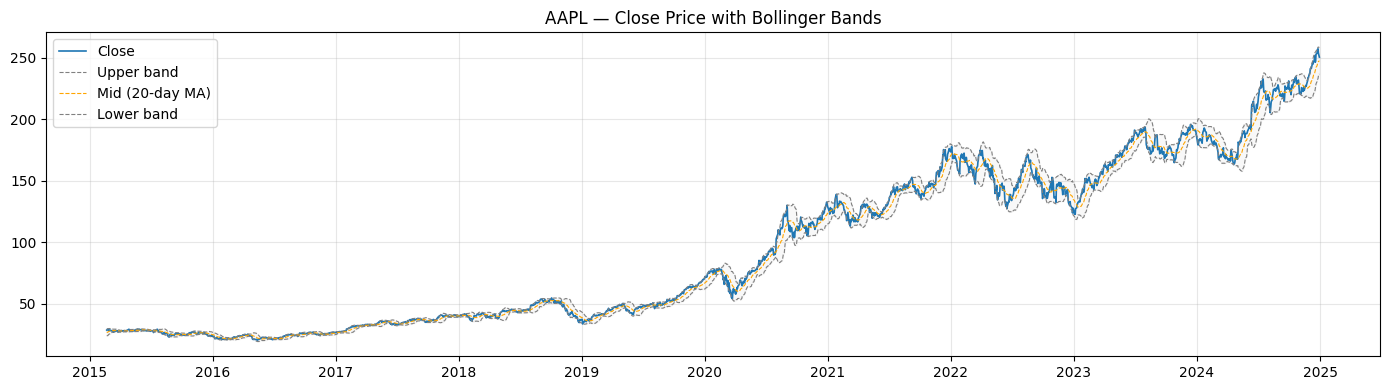

In [52]:
fig, ax = plt.subplots()
ax.plot(features.index, features['Close'], label='Close', linewidth=1.2)
ax.plot(features.index, features['bb_upper'], label='Upper band', linestyle='--', linewidth=0.8, color='grey')
ax.plot(features.index, features['bb_mid'],   label='Mid (20-day MA)', linestyle='--', linewidth=0.8, color='orange')
ax.plot(features.index, features['bb_lower'], label='Lower band', linestyle='--', linewidth=0.8, color='grey')
ax.fill_between(features.index, features['bb_upper'], features['bb_lower'], alpha=0.05, color='grey')
ax.set_title(f'{TICKER} — Close Price with Bollinger Bands')
ax.legend()
plt.tight_layout()
plt.show()

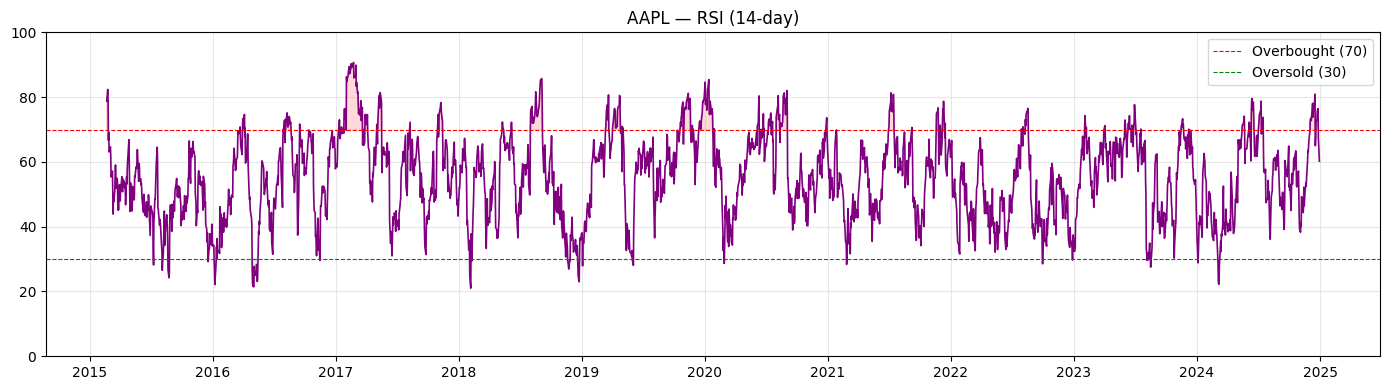

In [53]:
fig, ax = plt.subplots()
ax.plot(features.index, features['rsi'], linewidth=1.2, color='purple')
ax.axhline(70, linestyle='--', linewidth=0.8, color='red',   label='Overbought (70)')
ax.axhline(30, linestyle='--', linewidth=0.8, color='green', label='Oversold (30)')
ax.fill_between(features.index, features['rsi'], 70, where=(features['rsi'] >= 70), alpha=0.15, color='red')
ax.fill_between(features.index, features['rsi'], 30, where=(features['rsi'] <= 30), alpha=0.15, color='green')
ax.set_title(f'{TICKER} — RSI (14-day)')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

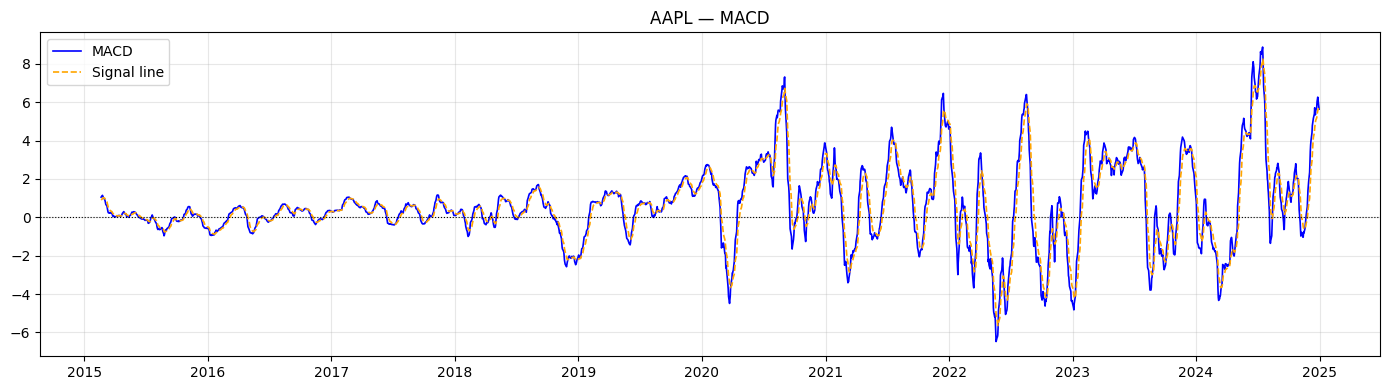

In [54]:
fig, ax = plt.subplots()
ax.plot(features.index, features['macd'],        label='MACD',         linewidth=1.2, color='blue')
ax.plot(features.index, features['macd_signal'], label='Signal line',  linewidth=1.2, color='orange', linestyle='--')
ax.axhline(0, linewidth=0.8, color='black', linestyle=':')
ax.set_title(f'{TICKER} — MACD')
ax.legend()
plt.tight_layout()
plt.show()

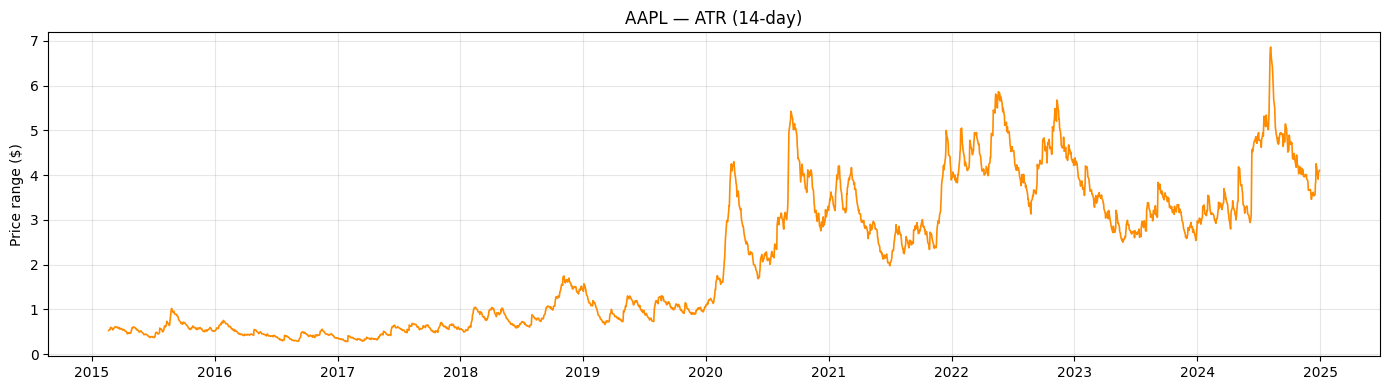

In [55]:
fig, ax = plt.subplots()
ax.plot(features.index, features['atr'], linewidth=1.2, color='darkorange')
ax.set_title(f'{TICKER} — ATR (14-day)')
ax.set_ylabel('Price range ($)')
plt.tight_layout()
plt.show()

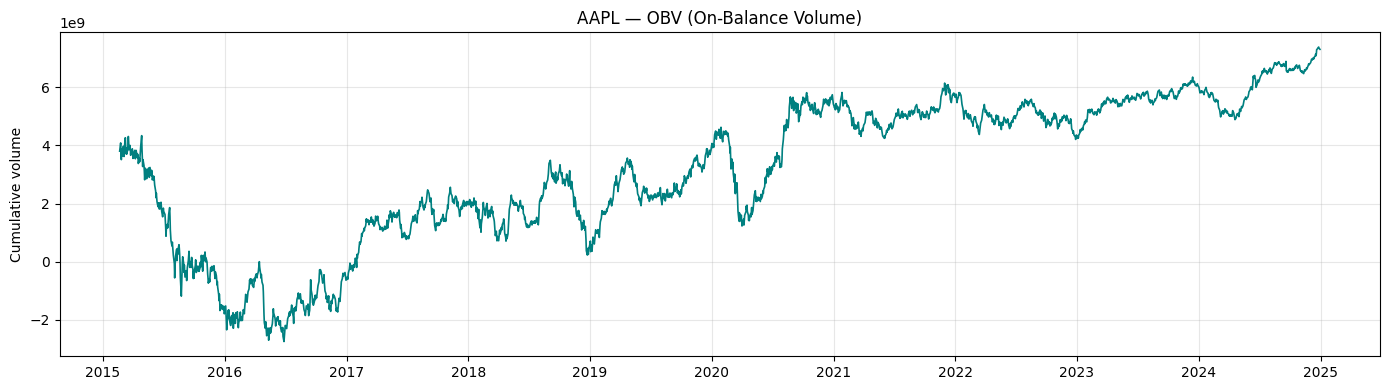

In [56]:
fig, ax = plt.subplots()
ax.plot(features.index, features['obv'], linewidth=1.2, color='teal')
ax.set_title(f'{TICKER} — OBV (On-Balance Volume)')
ax.set_ylabel('Cumulative volume')
plt.tight_layout()
plt.show()

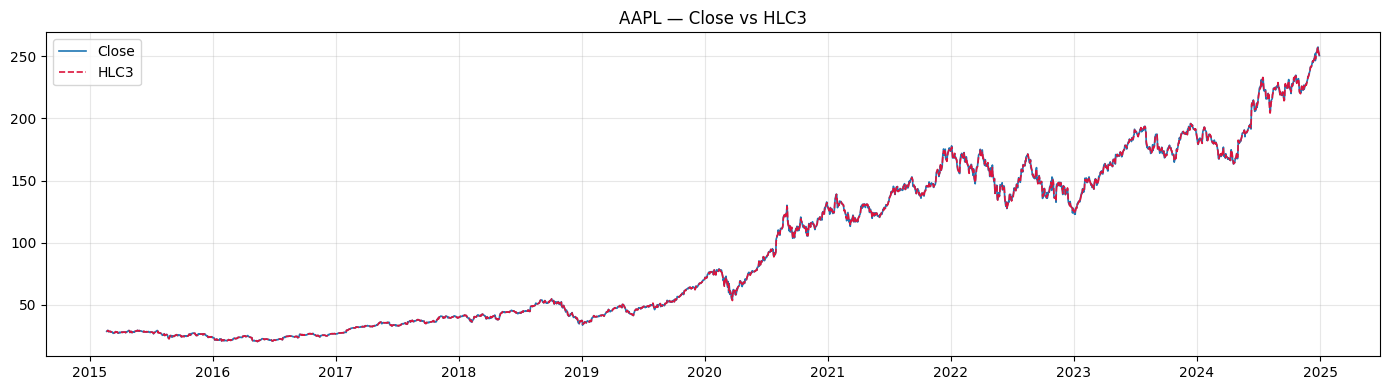

In [57]:
fig, ax = plt.subplots()
ax.plot(features.index, features['Close'], label='Close',  linewidth=1.2)
ax.plot(features.index, features['hlc3'],  label='HLC3',   linewidth=1.2, linestyle='--', color='crimson')
ax.set_title(f'{TICKER} — Close vs HLC3')
ax.legend()
plt.tight_layout()
plt.show()

## References

Mostafavi, S. M., & Hooman, A. R. (2025). Key technical indicators for stock market prediction. *Machine Learning with Applications*, 20, 100631. https://doi.org/10.1016/j.mlwa.2025.100631